# 02 — Dynamic Fee and Pool Imbalance

This notebook studies the StableSwap NG-style dynamic fee formula.

The goal is to visualize how the effective swap fee changes as a pool becomes imbalanced.

Core intuition:

> When the pool is balanced, the dynamic fee equals the base fee.  
> When the pool moves off-peg / off-balance, the effective fee increases.

Security relevance:

- dynamic fee is an economic guardrail against off-peg trading;
- fee behavior depends on normalized `xp` balances, not raw token balances;
- wrong rate / asset semantics can feed the fee formula incorrect value-space inputs.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from curve_stableswap_lab.scenarios import dynamic_fee_imbalance_grid, summarize_by_group
from curve_stableswap_lab.dynamic_fee import FEE_DENOMINATOR

In [2]:
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

FIGURE_DIR = ROOT / "outputs" / "figures"
TABLE_DIR = ROOT / "outputs" / "tables"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
base_fee = 4_000_000  # 4 bps under Curve's 1e10 fee denominator

multipliers = [
    FEE_DENOMINATOR,        # 1x, dynamic fee disabled
    2 * FEE_DENOMINATOR,    # 2x
    5 * FEE_DENOMINATOR,    # 5x
    10 * FEE_DENOMINATOR,   # 10x
]

ratios = [x / 100 for x in range(5, 96, 5)]

In [4]:
df = dynamic_fee_imbalance_grid(
    ratios=ratios,
    multipliers=multipliers,
    total_xp=2 * 10**18,
    base_fee=base_fee,
)

df.head()

,ratio,xpi,xpj,imbalance,imbalance_scaled,multiplier,multiplier_x,base_fee,base_fee_bps,effective_fee,effective_fee_bps
0,0.05,100000000000000000,1900000000000000000,0.9,900000000000000000,10000000000,1.0,4000000,4.0,4000000,4.000000
1,0.05,100000000000000000,1900000000000000000,0.9,900000000000000000,20000000000,2.0,4000000,4.0,6722689,6.722689
2,0.05,100000000000000000,1900000000000000000,0.9,900000000000000000,50000000000,5.0,4000000,4.0,11363636,11.363636
3,0.05,100000000000000000,1900000000000000000,0.9,900000000000000000,100000000000,10.0,4000000,4.0,14760147,14.760147
4,0.10,200000000000000000,1800000000000000000,0.8,800000000000000000,10000000000,1.0,4000000,4.0,4000000,4.000000


In [5]:
table_path = TABLE_DIR / "dynamic_fee_imbalance.csv"
df.to_csv(table_path, index=False)

table_path

PosixPath('/Users/chenxu/Work/artifacts/curve-stableswap-lab/outputs/tables/dynamic_fee_imbalance.csv')

In [6]:
midpoint = df[df["ratio"] == 0.5][
    [
        "ratio",
        "multiplier_x",
        "imbalance",
        "base_fee_bps",
        "effective_fee_bps",
    ]
]

midpoint

,ratio,multiplier_x,imbalance,base_fee_bps,effective_fee_bps
36,0.5,1.0,0.0,4.0,4.0
37,0.5,2.0,0.0,4.0,4.0
38,0.5,5.0,0.0,4.0,4.0
39,0.5,10.0,0.0,4.0,4.0


PosixPath('/Users/chenxu/Work/artifacts/curve-stableswap-lab/outputs/figures/dynamic_fee_imbalance.png')

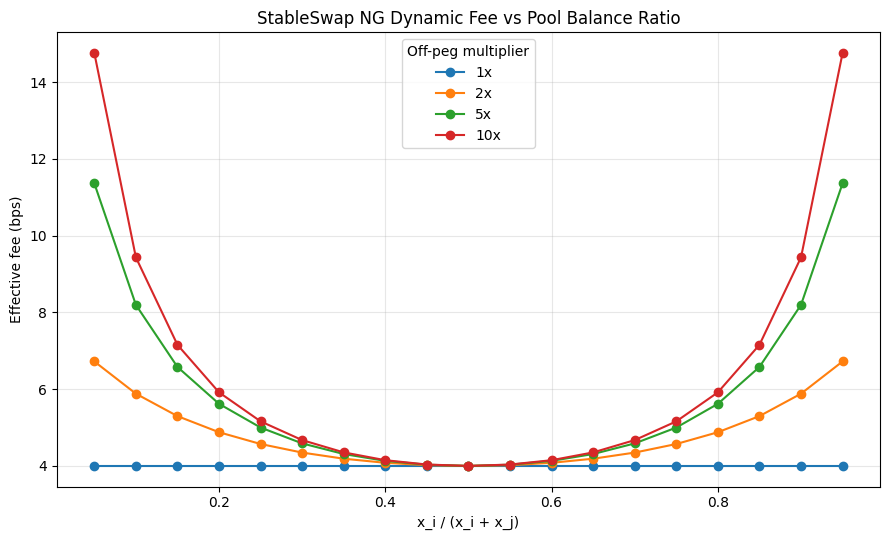

In [7]:
fig, ax = plt.subplots(figsize=(9, 5.5))

for multiplier_x, group in df.groupby("multiplier_x"):
    group = group.sort_values("ratio")
    ax.plot(
        group["ratio"],
        group["effective_fee_bps"],
        marker="o",
        label=f"{multiplier_x:g}x",
    )

ax.set_title("StableSwap NG Dynamic Fee vs Pool Balance Ratio")
ax.set_xlabel("x_i / (x_i + x_j)")
ax.set_ylabel("Effective fee (bps)")
ax.legend(title="Off-peg multiplier")
ax.grid(True, alpha=0.3)

figure_path = FIGURE_DIR / "dynamic_fee_imbalance.png"
fig.tight_layout()
fig.savefig(figure_path, dpi=160)

figure_path

PosixPath('/Users/chenxu/Work/artifacts/curve-stableswap-lab/outputs/figures/dynamic_fee_vs_imbalance.png')

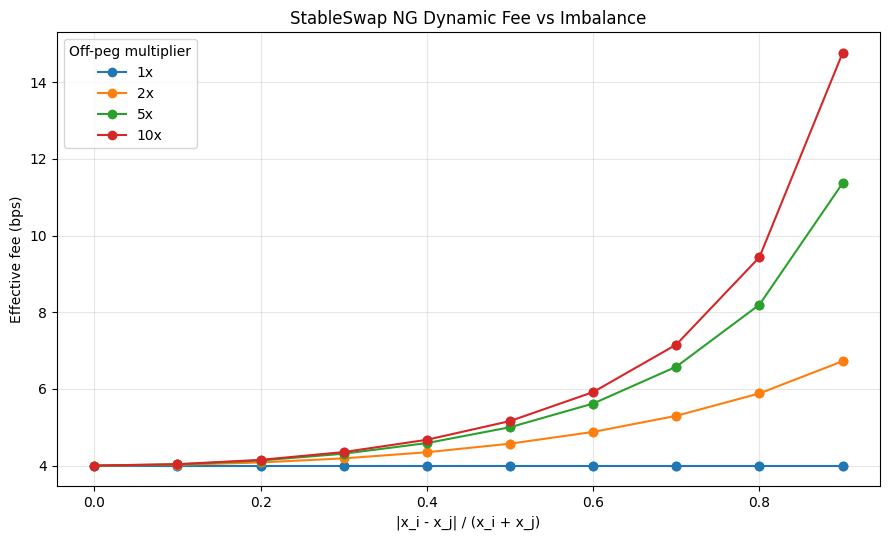

In [8]:
fig, ax = plt.subplots(figsize=(9, 5.5))

for multiplier_x, group in df.groupby("multiplier_x"):
    group = group.sort_values("imbalance")
    ax.plot(
        group["imbalance"],
        group["effective_fee_bps"],
        marker="o",
        label=f"{multiplier_x:g}x",
    )

ax.set_title("StableSwap NG Dynamic Fee vs Imbalance")
ax.set_xlabel("|x_i - x_j| / (x_i + x_j)")
ax.set_ylabel("Effective fee (bps)")
ax.legend(title="Off-peg multiplier")
ax.grid(True, alpha=0.3)

figure_path = FIGURE_DIR / "dynamic_fee_vs_imbalance.png"
fig.tight_layout()
fig.savefig(figure_path, dpi=160)

figure_path

In [9]:
summary = summarize_by_group(
    df,
    group_col="multiplier_x",
    value_col="effective_fee_bps",
)

summary

,multiplier_x,count,min,max,mean
0,1.0,19,4.0,4.000000,4.000000
1,2.0,19,4.0,6.722689,4.841113
2,5.0,19,4.0,11.363636,5.875713
3,10.0,19,4.0,14.760147,6.488353


In [10]:
max_fee_rows = (
    df.sort_values("effective_fee_bps", ascending=False)
    .head(10)
    [
        [
            "ratio",
            "imbalance",
            "multiplier_x",
            "base_fee_bps",
            "effective_fee_bps",
        ]
    ]
)

max_fee_rows

,ratio,imbalance,multiplier_x,base_fee_bps,effective_fee_bps
75,0.95,0.9,10.0,4.0,14.760147
3,0.05,0.9,10.0,4.0,14.760147
2,0.05,0.9,5.0,4.0,11.363636
74,0.95,0.9,5.0,4.0,11.363636
7,0.10,0.8,10.0,4.0,9.433962
71,0.90,0.8,10.0,4.0,9.433962
6,0.10,0.8,5.0,4.0,8.196721
70,0.90,0.8,5.0,4.0,8.196721
67,0.85,0.7,10.0,4.0,7.155635
11,0.15,0.7,10.0,4.0,7.155635


In [11]:
comparison = df[df["ratio"].isin([0.05, 0.5, 0.95])][
    [
        "ratio",
        "imbalance",
        "multiplier_x",
        "base_fee_bps",
        "effective_fee_bps",
    ]
].sort_values(["multiplier_x", "ratio"])

comparison

,ratio,imbalance,multiplier_x,base_fee_bps,effective_fee_bps
0,0.05,0.9,1.0,4.0,4.000000
36,0.50,0.0,1.0,4.0,4.000000
72,0.95,0.9,1.0,4.0,4.000000
1,0.05,0.9,2.0,4.0,6.722689
37,0.50,0.0,2.0,4.0,4.000000
73,0.95,0.9,2.0,4.0,6.722689
2,0.05,0.9,5.0,4.0,11.363636
38,0.50,0.0,5.0,4.0,4.000000
74,0.95,0.9,5.0,4.0,11.363636
3,0.05,0.9,10.0,4.0,14.760147


## Takeaways

The simulation confirms the expected StableSwap NG dynamic-fee behavior:

1. At balance, `x_i == x_j`, the dynamic fee equals the base fee.
2. If `offpeg_fee_multiplier <= FEE_DENOMINATOR`, the dynamic fee is effectively disabled.
3. As the pool becomes more imbalanced, the effective fee increases.
4. Higher off-peg multipliers produce higher fees for the same imbalance.

Security interpretation:

Dynamic fee is not just a trading-cost parameter. It depends on the same normalized value-space used by StableSwap math.

That means the fee formula is only as meaningful as its inputs:

```text
raw balances -> rates -> xp -> dynamic fee
```

If rates, asset types, or token semantics are misconfigured, the dynamic fee may be computed from an economically wrong representation of pool balance.

For auditors, dynamic fee should be reviewed together with:

- rate-provider precision and direction;
- ERC4626 share-price behavior;
- rebasing balance treatment;
- whether fee inputs are comparable xp values;
- whether quote and execution use the same state.